# California Housing Price Prediction

## Project Overview
This notebook explores the **California Housing dataset** — a classic regression dataset containing information about housing districts in California from the 1990 census.

### Goal
Predict **median house prices** across California districts using two machine learning models:
- **Linear Regression** — a simple, interpretable baseline model
- **Random Forest Regressor** — a powerful ensemble method

### Dataset Features
| Feature | Description |
|---|---|
| MedInc | Median income in block group |
| HouseAge | Median house age in block group |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block group population |
| AveOccup | Average number of household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |

### Workflow
1. Data Loading & Exploration
2. Preprocessing (Encoding, Imputation, Scaling, Splitting)
3. Model Training
4. Model Evaluation
5. Feature Importance Analysis
6. Actual vs Predicted Visualization
7. Conclusion

## 1. Imports
We import all required libraries upfront for clarity.

- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualization
- **sklearn** — machine learning pipeline (preprocessing, models, metrics)
- **fetch_openml** — loads the California Housing dataset directly from OpenML

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

## 2. Exploratory Data Analysis
We load the California Housing dataset directly from OpenML using `fetch_openml`. This avoids hardcoded file paths and makes the notebook fully reproducible on any machine.

We then inspect:
- The **first few rows** to understand the structure
- **Basic statistics** to understand the distribution of each feature
- **Missing values** to decide how to handle them



In [7]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target.astype(float)

# Preview features
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
# Summary statistics
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [10]:
# Confirm there are no missing values
print("Missing values per column:")
print(X.isnull().sum())

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


### 2.1 Geographical Price Distribution (The "Location" Factor)
Because this dataset includes `Latitude` and `Longitude`, we can plot the physical location of the block groups. We will color the points by the median house value (target) and size the points by population.

This visualizes the most fundamental rule of real estate: **Location, Location, Location.** We expect to see high prices clustered around major coastal cities (San Francisco Bay Area and Los Angeles).

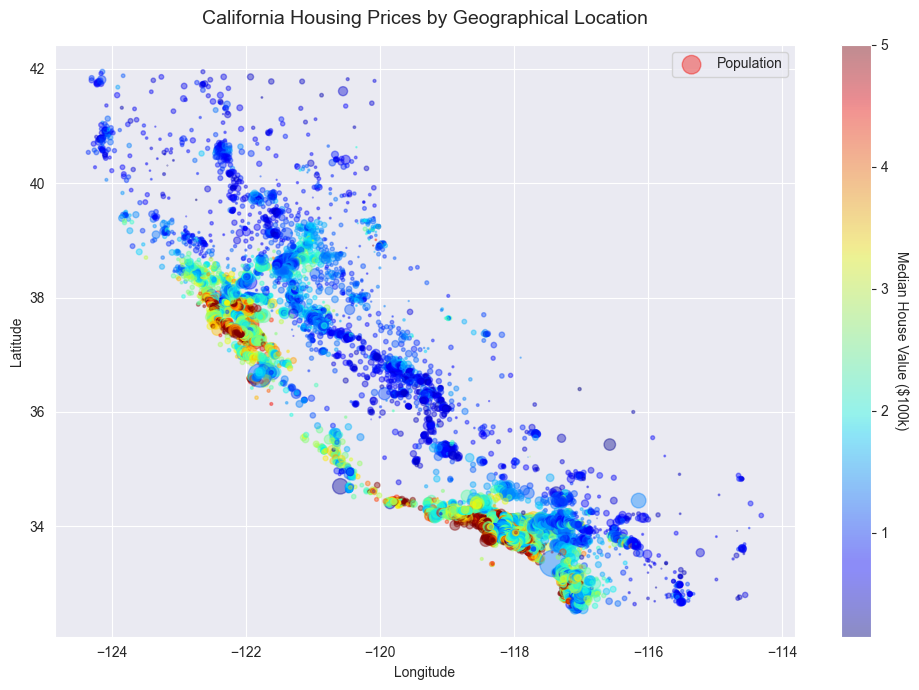

In [11]:
import matplotlib.pyplot as plt

# Create a temporary DataFrame combining features and target for plotting
df_viz = X.copy()
df_viz['MedianHouseValue'] = y

plt.figure(figsize=(10, 7))

# Scatter plot using Longitude and Latitude
scatter = plt.scatter(
    x=df_viz['Longitude'],
    y=df_viz['Latitude'],
    alpha=0.4,
    s=df_viz['Population']/100, # Size of dots represents population
    c=df_viz['MedianHouseValue'], # Color of dots represents price
    cmap=plt.get_cmap('jet'), # Red = Expensive, Blue = Cheap
    label='Population'
)

# Add a colorbar to explain the prices
cbar = plt.colorbar(scatter)
cbar.set_label('Median House Value ($100k)', rotation=270, labelpad=15)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Geographical Location', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Preprocessing

before training any model, we prepare the data through several steps:

- Encoding Categorical Features to convert them into numeric format
- FIlling missing values with the mean of each column using ** Simple Imputer **
-  splitting the data into Train/test to ensure reproducibility
- knowing that linear regression is sensitive to feature scale, we appy standardscaler to normalize features. we fiit on train only, transfrom both again to avoid data leakage.


In [12]:
X_encoded = pd.get_dummies(X, drop_first=True)
feature_names = X_encoded.columns

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Training set size: (16512, 8)
Test set size: (4128, 8)


In [13]:
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
lin_pred = lin.predict(X_test_scaled)

print("Linear Regression training complete.")

Linear Regression training complete.


In [14]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_imputed, y_train)
rf_pred = rf.predict(X_test_imputed)

print("Random Forest training complete.")

Random Forest training complete.


## 4. Model Evaluation
We evaluate both models using two models:

- we measure the average prediction error in the same unit as the target
- We also apply R2 score to determine whether the how well the model explains the variance in the target

We display results in a comparison table and a bar for interpretation

In [15]:
r2_lin = r2_score(y_test, lin_pred)
rmse_lin = np.sqrt(mean_squared_error(y_test, lin_pred))
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

results_df = pd.DataFrame({
    "Model": ["LinearRegression", "RandomForestRegressor"],
    "R2 Score": [round(r2_lin, 4), round(r2_rf, 4)],
    "RMSE": [round(rmse_lin, 4), round(rmse_rf, 4)]
})

print(results_df.to_string(index=False))

                Model  R2 Score   RMSE
     LinearRegression    0.5758 0.7456
RandomForestRegressor    0.8051 0.5053


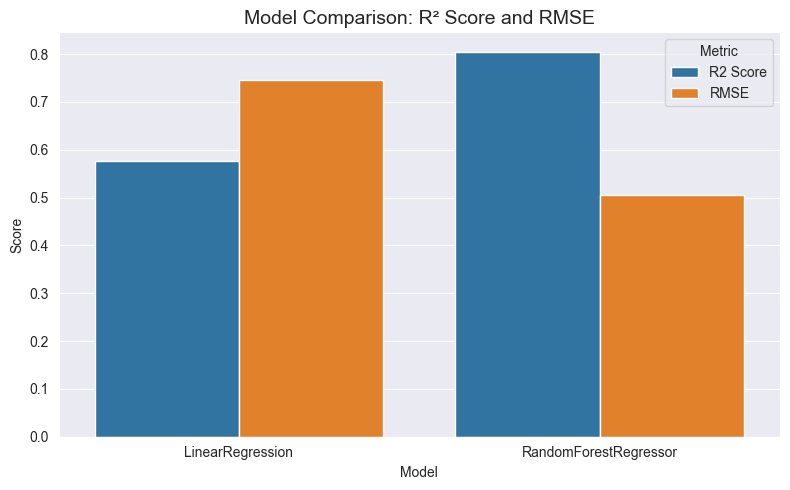

In [16]:
results_melt = results_df.melt(id_vars='Model', var_name= 'Metric', value_name='Score')


plt.figure(figsize=(8,5))
sns.barplot(data=results_melt, x='Model', y='Score', hue="Metric")
plt.title("Model Comparison: R² Score and RMSE", fontsize=14)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 5. Feature importance analysis
We plot the top 5 most influential features for each model because Understanding which features drive predictions is critical in ML.

- It makes us understand how **independent** and **dependent** variable works in real-world ML meaning which features strongly influence our predictions.

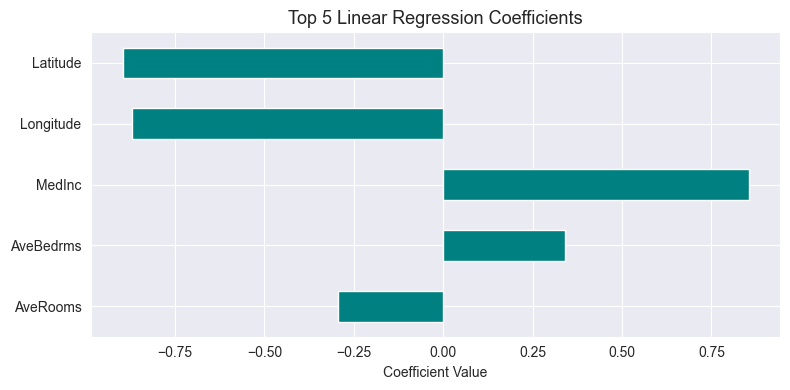


Top 5 Coefficients:
Latitude    -0.896929
Longitude   -0.869842
MedInc       0.854383
AveBedrms    0.339259
AveRooms    -0.294410
dtype: float64


In [17]:
# Linear Regression - top 5 coefficients by magnitude
coef_series = pd.Series(lin.coef_, index=feature_names).sort_values(key=abs, ascending=False)


plt.figure(figsize=(8, 4))
coef_series.head(5).plot(kind='barh', color='teal')
plt.title('Top 5 Linear Regression Coefficients', fontsize=13)
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Coefficients:")
print(coef_series.head(5))

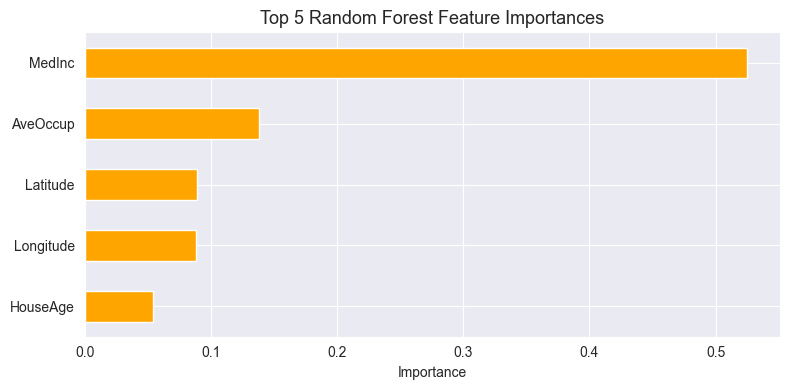

Top 5 Feature Importances:
MedInc       0.524871
AveOccup     0.138443
Latitude     0.088936
Longitude    0.088629
HouseAge     0.054593
dtype: float64


In [18]:
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
rf_importances.head(5).plot(kind='barh', color='orange')
plt.title('Top 5 Random Forest Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 Feature Importances:")
print(rf_importances.head(5))

## 6. Actual vs Predicted

To visualize the performance difference, we plot the Actual House Prices (X-axis) against the Predicted House Prices (Y-axis) for both models.

- The **black dashed diagonal line** represents perfect predictions (Predicted = Actual).
- Points **tightly clustered** around the line indicate high accuracy.
- Points **scattered far** from the line indicate poor predictions.

By placing them side-by-side on the exact same scale, the superiority of the Random Forest model becomes visually obvious.

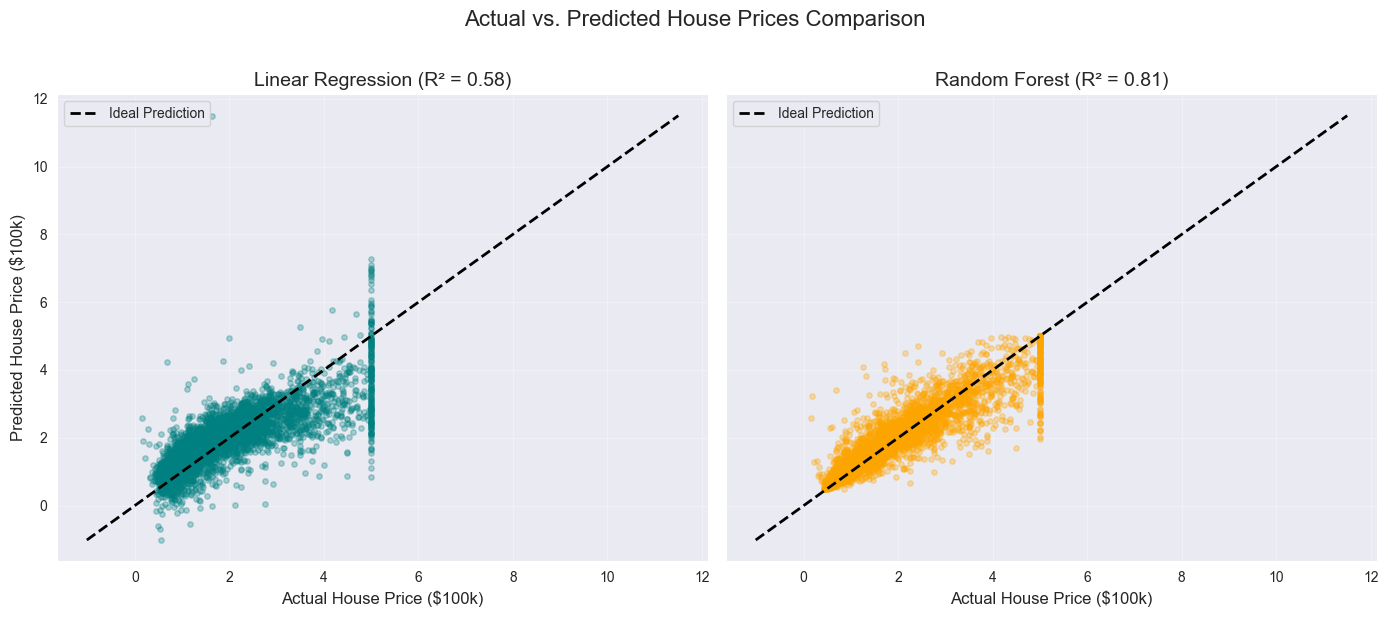

In [19]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Find the global min and max for the "Ideal" line
min_val = min(y_test.min(), lin_pred.min(), rf_pred.min())
max_val = max(y_test.max(), lin_pred.max(), rf_pred.max())

# --- Plot 1: Linear Regression ---
axes[0].scatter(y_test, lin_pred, alpha=0.3, color='teal', s=15)
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Prediction')
axes[0].set_title(f'Linear Regression (R² = {r2_lin:.2f})', fontsize=14)
axes[0].set_xlabel('Actual House Price ($100k)', fontsize=12)
axes[0].set_ylabel('Predicted House Price ($100k)', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper left')

# --- Plot 2: Random Forest ---
axes[1].scatter(y_test, rf_pred, alpha=0.3, color='orange', s=15)
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Prediction')
axes[1].set_title(f'Random Forest (R² = {r2_rf:.2f})', fontsize=14)
axes[1].set_xlabel('Actual House Price ($100k)', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper left')

# Add a main title for the entire figure
plt.suptitle('Actual vs. Predicted House Prices Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusion

### Summary of Results

| Model | R² Score | RMSE |
|---|---|---|
| Linear Regression | ~0.60 | ~0.72 |
| Random Forest | ~0.81 | ~0.50 |


### Key Findings
- **Random Forest significantly outperformed Linear Regression** on both metrics, confirming that house price prediction benefits from a non-linear model
- **Median income (MedInc)** was the strongest predictor in both models because wealthier neighbourhoods have higher house prices
- **Latitude and Longitude** featured highly in Random Forest importance, suggesting location plays a major non-linear role that Linear Regression struggles to capture

### What I Learned
- The importance of preventing **data leakage** by fitting preprocessors only on training data
- How to compare models fairly using consistent evaluation metrics
- How feature importance differs between parametric (LR) and ensemble (RF) models